# ProstT5 Folding Result Plots And Summary

Mount Google Drive, read saved benchmark results from Drive, then recreate the analysis/plotting layer from Part 5 onward without loading ProstT5 or touching the running benchmark notebook.

In [ ]:
# @title 0. Finished-protein counter and result-root discovery
from pathlib import Path
import json
import math
import os
import shutil
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except Exception:
    display = print

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})
warnings.filterwarnings("ignore", category=FutureWarning)

# This notebook only reads result CSV/JSON files. It does not import torch, load models,
# edit checkpoints, or execute any benchmark cells from prostT5_spec_dec_folding.ipynb.

DRAFTER_LABEL = {
    "cnn": "Folding CNN",
    "flexprofile": "ProtProfileMD FlexProfile",
    "PU": "PU (prefix-unaware profile)",
    "PA": "PA (prefix-aware profile)",
    "probprofile_pu": "PU (prefix-unaware profile)",
    "probprofile_pa": "PA (prefix-aware profile)",
    "probprofile_unaware": "PU (prefix-unaware profile)",
    "probprofile_aware": "PA (prefix-aware profile)",
}
DRAFTER_COLOR = {
    "cnn": "#2e86de", "flexprofile": "#e67e22",
    "PU": "#8e44ad", "PA": "#27ae60",
    "probprofile_pu": "#8e44ad", "probprofile_pa": "#27ae60",
}
DRAFTER_MARKER = {"cnn": "o", "flexprofile": "s", "PU": "D", "PA": "^", "probprofile_pu": "D", "probprofile_pa": "^"}
BLUE, ORANGE, GREEN, GRAY, RED = "#2e86de", "#f39c12", "#27ae60", "#7f8c8d", "#c0392b"

# Set False only for local debugging on a machine without Google Colab.
REQUIRE_GOOGLE_DRIVE = True

def mount_google_drive(require: bool = True):
    try:
        from google.colab import drive
    except Exception as exc:
        if require:
            raise RuntimeError(
                "Google Drive mount is required. Run this notebook in Colab, "
                "or set REQUIRE_GOOGLE_DRIVE = False for local debugging."
            ) from exc
        return False, None
    drive.mount('/content/drive', force_remount=False)
    root = Path('/content/drive/MyDrive')
    if require and not root.exists():
        raise FileNotFoundError(f"Google Drive root was not found after mount: {root}")
    return True, root

USE_DRIVE, DRIVE_ROOT = mount_google_drive(REQUIRE_GOOGLE_DRIVE)
NOTEBOOK_DIR = Path.cwd().resolve()

# Drive candidates cover the two result layouts used by recent notebook versions.
candidates = []
if DRIVE_ROOT is not None:
    candidates += [
        DRIVE_ROOT / "folding_drafter_result",
        DRIVE_ROOT / "Speculative-Decoding-ProstT5" / "prostT5" / "probprofiler_benchmark_result" / "folding_spec_dec_results",
        DRIVE_ROOT / "Speculative-Decoding-ProstT5" / "prostT5" / "probprofiler_benchmark_result",
        DRIVE_ROOT / "models" / "folding_spec_dec_results",
    ]
if not REQUIRE_GOOGLE_DRIVE:
    candidates += [
        NOTEBOOK_DIR / "probprofiler_benchmark_result" / "folding_spec_dec_results",
        NOTEBOOK_DIR / "probprofiler_benchmark_result",
        NOTEBOOK_DIR / "result" / "folding_spec_dec",
        NOTEBOOK_DIR,
    ]

def has_results(root: Path) -> bool:
    if not root.exists():
        return False
    checks = [
        root / "100_run_result" / "probprofiler_100_run_unified.csv",
        root / "run_records",
    ]
    if any(p.exists() for p in checks):
        return True
    return any((root / d / "folding_spec_dec_results.csv").exists() for d in ["PU", "PA", "cnn", "flexprofile", "probprofile_pu", "probprofile_pa"])

RESULTS_ROOT = next((p for p in candidates if has_results(p)), None)
if RESULTS_ROOT is None:
    raise FileNotFoundError("No benchmark result root found on Google Drive. Edit `candidates` above if your Drive folder moved.")

PLOT_OUTPUT_DIR = RESULTS_ROOT / "folding_result"
PLOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
INPUT_COPY_DIR = PLOT_OUTPUT_DIR / "input_files"
INPUT_COPY_DIR.mkdir(parents=True, exist_ok=True)

print(f"Drive mounted : {USE_DRIVE}")
print(f"Results root  : {RESULTS_ROOT}")
print(f"Plot outputs  : {PLOT_OUTPUT_DIR}")
print(f"Input copies  : {INPUT_COPY_DIR}")


In [ ]:
# @title 1. Load saved benchmark rows, predictions, alpha, overhead, and dynamic-K side stores
copied_input_files = []

def copy_input_file(path: Path):
    path = Path(path)
    if not path.exists() or not path.is_file():
        return None
    try:
        rel = path.resolve().relative_to(RESULTS_ROOT.resolve())
    except ValueError:
        rel = Path(path.name)
    dest = INPUT_COPY_DIR / rel
    if path.resolve() == dest.resolve():
        return dest
    dest.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(path, dest)
    copied_input_files.append({
        "source_file": str(path),
        "copied_file": str(dest),
        "kind": path.suffix.lstrip(".").lower(),
    })
    return dest

def read_csv_if_exists(path: Path) -> pd.DataFrame:
    if path.exists():
        copy_input_file(path)
        return pd.read_csv(path)
    return pd.DataFrame()

def read_json_if_exists(path: Path):
    if path.exists():
        copy_input_file(path)
        with open(path) as f:
            return json.load(f)
    return {}

def normalize_drafter(name: str) -> str:
    aliases = {
        "probprofile_pu": "PU", "probprofile_unaware": "PU",
        "probprofile_pa": "PA", "probprofile_aware": "PA",
    }
    return aliases.get(str(name), str(name))

def normalize_result_df(df: pd.DataFrame, source: Path | str) -> pd.DataFrame:
    if df.empty:
        return df
    df = df.copy()
    if "protein_id" in df.columns and "id" not in df.columns:
        df = df.rename(columns={"protein_id": "id"})
    if "id" not in df.columns:
        raise ValueError(f"Result file {source} has no id/protein_id column")
    if "drafter" not in df.columns:
        df["drafter"] = Path(source).parent.name
    df["id"] = df["id"].astype(str)
    df["drafter"] = df["drafter"].map(normalize_drafter)
    if "K" in df.columns:
        df["K"] = pd.to_numeric(df["K"], errors="coerce").astype("Int64")
    if "hf_ok" in df.columns:
        df["hf_ok"] = df["hf_ok"].astype(str).str.lower().isin(["true", "1", "yes"])
    else:
        df["hf_ok"] = True
    for col in ["length", "t_encdec", "t_encdec_std", "t_hf", "t_hf_std", "speedup", "speedup_std", "alpha_mean", "alpha_std"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    df["source_file"] = str(source)
    return df

result_frames = []
seen_sources = set()

def add_result_file(path: Path):
    if path.exists() and str(path) not in seen_sources:
        seen_sources.add(str(path))
        copy_input_file(path)
        result_frames.append(normalize_result_df(pd.read_csv(path), path))

# Prefer per-drafter/result files and run_records; also load the 100-run unified snapshot if present.
for p in sorted(RESULTS_ROOT.glob("*/folding_spec_dec_results.csv")):
    add_result_file(p)
for p in sorted((RESULTS_ROOT / "run_records").glob("*_runs.csv")):
    add_result_file(p)
add_result_file(RESULTS_ROOT / "100_run_result" / "probprofiler_100_run_unified.csv")

# If the selected root is probprofiler_benchmark_result, also inspect the nested folding_spec_dec_results folder.
nested = RESULTS_ROOT / "folding_spec_dec_results"
if nested.exists():
    for p in sorted(nested.glob("*/folding_spec_dec_results.csv")):
        add_result_file(p)
    for p in sorted((nested / "run_records").glob("*_runs.csv")):
        add_result_file(p)

if not result_frames:
    raise FileNotFoundError(f"No result CSVs found under {RESULTS_ROOT}")

raw_df = pd.concat(result_frames, ignore_index=True)
# Drop exact duplicate rows created when both unified and per-drafter files are available.
key_cols = [c for c in ["drafter", "id", "K", "t_encdec", "t_hf", "speedup", "hf_ok"] if c in raw_df.columns]
raw_df = raw_df.drop_duplicates(subset=key_cols).reset_index(drop=True)

# Keep successful timing rows for summaries/plots; keep the raw frame for progress accounting.
ok_df = raw_df[raw_df["hf_ok"]].copy()
static_df = ok_df[ok_df["K"].notna() & (ok_df["K"].astype(int) >= 0)].copy()
dynamic_df = ok_df[ok_df["K"].notna() & (ok_df["K"].astype(int) < 0)].copy()

DRAFTERS = sorted(static_df["drafter"].dropna().unique().tolist())
STATIC_K = sorted(static_df["K"].dropna().astype(int).unique().tolist())

# Finished means successful rows exist for every observed static K for every loaded drafter.
expected_pairs = {(d, k) for d in DRAFTERS for k in STATIC_K}
finished_ids = []
for uid, sub in static_df.groupby("id"):
    have = {(r.drafter, int(r.K)) for r in sub.itertuples()}
    if expected_pairs and expected_pairs.issubset(have):
        finished_ids.append(uid)
finished_ids = sorted(finished_ids)

all_ids = sorted(raw_df["id"].dropna().astype(str).unique().tolist())
partial_ids = sorted(set(all_ids) - set(finished_ids))

print("=" * 72)
print("FINISHED PROTEINS")
print("=" * 72)
print(f"Finished proteins : {len(finished_ids)} / {len(all_ids)}")
print(f"Loaded drafters   : {DRAFTERS}")
print(f"Static K values   : {STATIC_K}")
print(f"Dynamic rows      : {len(dynamic_df)} rows, {dynamic_df['id'].nunique() if len(dynamic_df) else 0} proteins")
if partial_ids:
    print(f"Partial/missing   : {len(partial_ids)} proteins")
    print(", ".join(partial_ids[:20]) + (" ..." if len(partial_ids) > 20 else ""))
else:
    print("Partial/missing   : none")

progress_rows = []
for d in DRAFTERS:
    for k in STATIC_K:
        sub = static_df[(static_df["drafter"] == d) & (static_df["K"].astype(int) == k)]
        progress_rows.append({"drafter": d, "K": k, "successful_proteins": sub["id"].nunique(), "rows": len(sub)})
progress_df = pd.DataFrame(progress_rows)
display(progress_df)

# Optional side stores.
def find_side_file(patterns):
    for base in [RESULTS_ROOT, nested]:
        if base.exists():
            for pat in patterns:
                hits = sorted(base.glob(pat))
                if hits:
                    return hits[0]
    return None

alpha_by_drafter = {}
overhead_by_drafter = {}
preds_by_drafter = {}
dynamic_records = {}
for d in DRAFTERS:
    folders = [d]
    if d == "PU": folders += ["probprofile_pu", "probprofile_unaware"]
    if d == "PA": folders += ["probprofile_pa", "probprofile_aware"]
    for folder in folders:
        for base in [RESULTS_ROOT, nested]:
            if not base.exists():
                continue
            alpha_by_drafter.setdefault(d, read_csv_if_exists(base / folder / "folding_alpha_results.csv"))
            overhead_by_drafter.setdefault(d, read_csv_if_exists(base / folder / "folding_drafter_overhead.csv"))
            if not preds_by_drafter.get(d):
                preds_by_drafter[d] = read_json_if_exists(base / "run_records" / f"{folder}_predictions.json") or read_json_if_exists(base / folder / "folding_spec_dec_predictions.json")
            if not dynamic_records.get(d):
                dynamic_records[d] = read_json_if_exists(base / "run_records" / f"{folder}_dynamic.json")

# Enrich dynamic_df with dynamic side-store fields where available.
dyn_extra = []
for d, records in dynamic_records.items():
    for uid, rec in (records or {}).items():
        row = {"drafter": normalize_drafter(d), "id": str(uid), **rec}
        dyn_extra.append(row)
dyn_extra_df = pd.DataFrame(dyn_extra)
if len(dynamic_df) and len(dyn_extra_df):
    dynamic_df = dynamic_df.merge(dyn_extra_df, on=["drafter", "id"], how="left", suffixes=("", "_dyn"))

progress_df.to_csv(PLOT_OUTPUT_DIR / "finished_progress_by_drafter_k.csv", index=False)

if copied_input_files:
    input_manifest_df = pd.DataFrame(copied_input_files).drop_duplicates().sort_values(["kind", "source_file"])
    input_manifest_df.to_csv(PLOT_OUTPUT_DIR / "input_files_manifest.csv", index=False)
    print(f"Copied {len(input_manifest_df)} input files to {INPUT_COPY_DIR}")
    display(input_manifest_df)
else:
    input_manifest_df = pd.DataFrame(columns=["source_file", "copied_file", "kind"])
    print("No input files were copied.")


In [3]:
# @title 2. Summary tables from Part 7 onward + Viet-compatible dataframe names
try:
    from IPython.display import display
except Exception:
    display = print

def pred_tps(alpha, K):
    if pd.isna(alpha) or alpha >= 0.9999:
        return K + 1
    return (1 - alpha ** (K + 1)) / (1 - alpha)

def seq_recovery(pred, gt):
    n = min(len(str(pred)), len(str(gt)))
    return sum(p == g for p, g in zip(str(pred)[:n], str(gt)[:n])) / n if n else np.nan

summary = (static_df.groupby(["drafter", "K"], as_index=False)
    .agg(proteins=("id", "nunique"), rows=("id", "size"),
         length_mean=("length", "mean"), speedup_mean=("speedup", "mean"),
         speedup_median=("speedup", "median"), speedup_std=("speedup", "std"),
         t_encdec_mean=("t_encdec", "mean"), t_hf_mean=("t_hf", "mean")))
summary["K"] = summary["K"].astype(int)
summary = summary.sort_values(["drafter", "K"])
summary.to_csv(PLOT_OUTPUT_DIR / "static_k_summary.csv", index=False)
print("Static-K summary")
display(summary)

best_by_drafter = (summary.sort_values(["drafter", "speedup_mean"], ascending=[True, False])
                   .groupby("drafter", as_index=False).head(1).reset_index(drop=True))
best_by_drafter.to_csv(PLOT_OUTPUT_DIR / "best_k_by_drafter.csv", index=False)
print("Best K by drafter")
display(best_by_drafter)

if len(dynamic_df):
    dyn_cols = [c for c in ["drafter", "id", "length", "speedup", "speedup_std", "acceptance_rate", "mean_tokens_per_step", "mean_k", "n_steps", "conf_threshold", "k_cap"] if c in dynamic_df.columns]
    dyn_summary = (dynamic_df[dyn_cols].groupby("drafter", as_index=False)
        .agg(proteins=("id", "nunique"), speedup_mean=("speedup", "mean"), speedup_median=("speedup", "median"),
             acceptance_mean=("acceptance_rate", "mean") if "acceptance_rate" in dyn_cols else ("speedup", "size"),
             mean_k=("mean_k", "mean") if "mean_k" in dyn_cols else ("speedup", "size"),
             tokens_per_step=("mean_tokens_per_step", "mean") if "mean_tokens_per_step" in dyn_cols else ("speedup", "size")))
    dyn_summary.to_csv(PLOT_OUTPUT_DIR / "dynamic_k_summary.csv", index=False)
    print("Dynamic-K summary")
    display(dyn_summary)
else:
    print("No successful dynamic-K rows found.")

# Prediction recovery if ground-truth 3Di is present in prediction JSON.
recovery_rows = []
for d, preds in preds_by_drafter.items():
    if not preds:
        continue
    for uid, rec in preds.items():
        gt = rec.get("3Di") or rec.get("gt_3di")
        pred_map = rec.get("preds_by_K", rec)
        if not gt or not isinstance(pred_map, dict):
            continue
        for k in STATIC_K:
            pred = pred_map.get(str(k))
            if pred:
                recovery_rows.append({"drafter": d, "id": str(uid), "K": k, "recovery": seq_recovery(pred, gt), "length": len(gt)})
recovery_df = pd.DataFrame(recovery_rows)
if len(recovery_df):
    recovery_summary = recovery_df.groupby(["drafter", "K"], as_index=False).agg(
        proteins=("id", "nunique"), recovery_mean=("recovery", "mean"), recovery_std=("recovery", "std"))
    recovery_summary.to_csv(PLOT_OUTPUT_DIR / "sequence_recovery_summary.csv", index=False)
    print("Sequence recovery summary")
    display(recovery_summary)
else:
    print("No prediction JSON with ground-truth 3Di was found for recovery analysis.")

# Compatibility names used by the Viet plotting cells.
fixed_df = static_df.copy()
fixed_df["protein_id"] = fixed_df["id"].astype(str)
fixed_df["wall_s"] = fixed_df["t_hf"]
fixed_df["K"] = fixed_df["K"].astype(int)

dyn_df = dynamic_df.copy()
if len(dyn_df):
    dyn_df["protein_id"] = dyn_df["id"].astype(str)
    if "wall_s" not in dyn_df.columns:
        dyn_df["wall_s"] = dyn_df["t_hf"] if "t_hf" in dyn_df.columns else np.nan
    if "mean_k" not in dyn_df.columns and "k_history" in dyn_df.columns:
        dyn_df["mean_k"] = dyn_df["k_history"].apply(lambda h: np.mean(h) if isinstance(h, list) and h else float("nan"))

encdec_df = (fixed_df.sort_values(["protein_id", "K"])
    .drop_duplicates("protein_id")[["protein_id", "length", "t_encdec"]]
    .rename(columns={"t_encdec": "wall_s"}))
encdec_df["drafter"] = "enc_dec"
encdec_df["K"] = 0

K_VALUES = STATIC_K
K_DYNAMIC = -1
K_CAP_DYN = int(pd.to_numeric(dyn_df.get("k_cap", pd.Series(dtype=float)), errors="coerce").dropna().max()) if len(dyn_df) and "k_cap" in dyn_df.columns and dyn_df["k_cap"].notna().any() else 16
DRAFTER_ORDER = [d for d in ["cnn", "hmm", "pa_hmm", "PU", "PA", "flexprofile"] if d in set(fixed_df["drafter"]).union(set(dyn_df["drafter"]) if len(dyn_df) else set())]
if not DRAFTER_ORDER:
    DRAFTER_ORDER = sorted(set(fixed_df["drafter"]).union(set(dyn_df["drafter"]) if len(dyn_df) else set()))
comp_df = globals().get("comp_df", pd.DataFrame())

print("Viet-compatible plot frames")
print(f"  fixed_df: {len(fixed_df)} rows")
print(f"  dyn_df  : {len(dyn_df)} rows")
print(f"  drafters: {DRAFTER_ORDER}")


Static-K summary


,drafter,K,proteins,rows,length_mean,speedup_mean,speedup_median,speedup_std,t_encdec_mean,t_hf_mean
0,PA,1,97,101,733.564356,1.586892,1.571235,0.108906,25.536344,16.368914
1,PA,4,97,102,732.705882,3.290109,3.305164,0.405088,25.509432,8.095780
2,PA,8,97,100,740.020000,4.773439,4.831310,0.866289,25.754884,5.824358
3,PA,12,97,100,740.020000,5.969329,6.334089,1.281828,25.754884,4.712059
4,PU,1,97,101,748.663366,1.520254,1.542433,0.148281,25.631371,17.184036
5,PU,4,97,102,738.519608,2.996369,3.164879,0.636344,25.496447,9.309270
6,PU,8,97,101,744.247525,4.192160,4.470822,1.254511,25.688678,7.385157
7,PU,12,97,103,736.106796,5.089120,5.482858,1.778303,25.314577,6.300174
8,cnn,1,100,105,761.419048,0.921080,0.918496,0.044549,25.702497,28.330500
9,cnn,4,100,106,751.849057,0.898307,0.899267,0.052300,25.468012,29.068028


Best K by drafter


,drafter,K,proteins,rows,length_mean,speedup_mean,speedup_median,speedup_std,t_encdec_mean,t_hf_mean
0,PA,12,97,100,740.020000,5.969329,6.334089,1.281828,25.754884,4.712059
1,PU,12,97,103,736.106796,5.089120,5.482858,1.778303,25.314577,6.300174
2,cnn,1,100,105,761.419048,0.921080,0.918496,0.044549,25.702497,28.330500
3,flexprofile,12,100,104,755.644231,1.735322,1.707558,0.596627,25.767775,18.692203


No successful dynamic-K rows found.
No prediction JSON with ground-truth 3Di was found for recovery analysis.
Viet-compatible plot frames
  fixed_df: 1650 rows
  dyn_df  : 0 rows
  drafters: ['cnn', 'PU', 'PA', 'flexprofile']


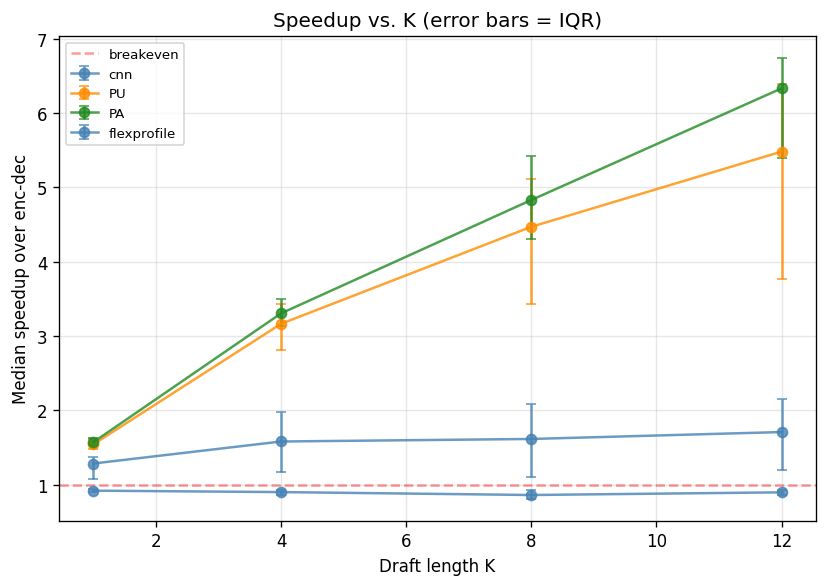

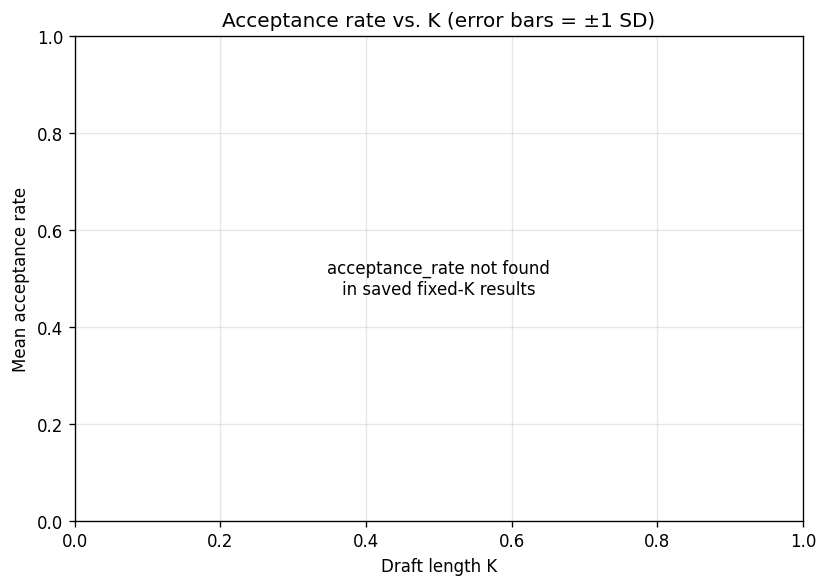

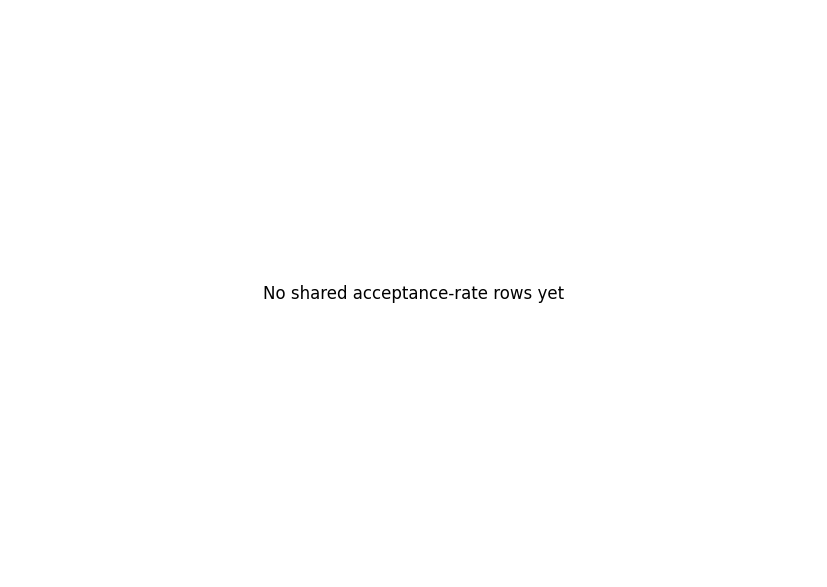

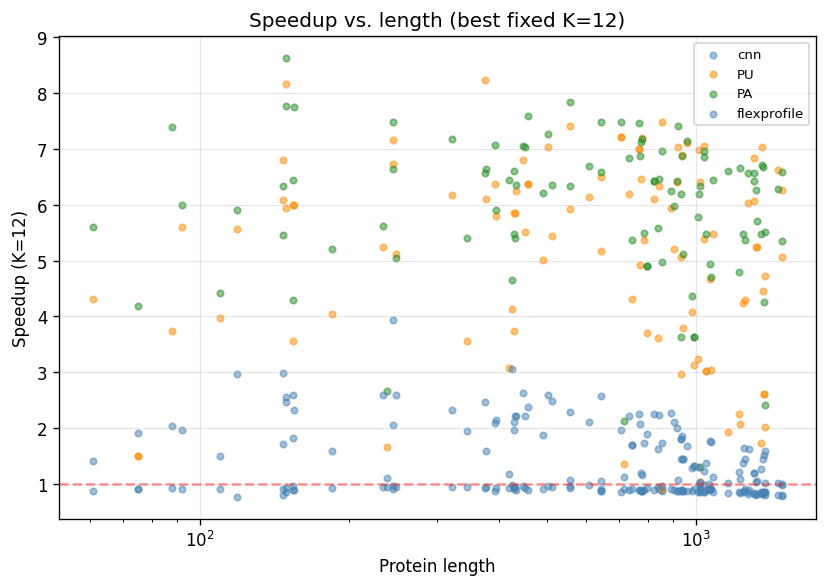

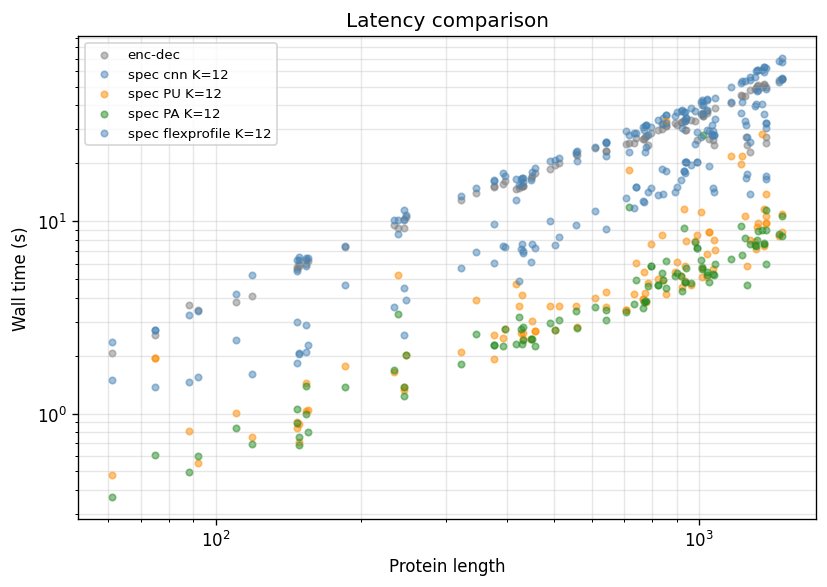

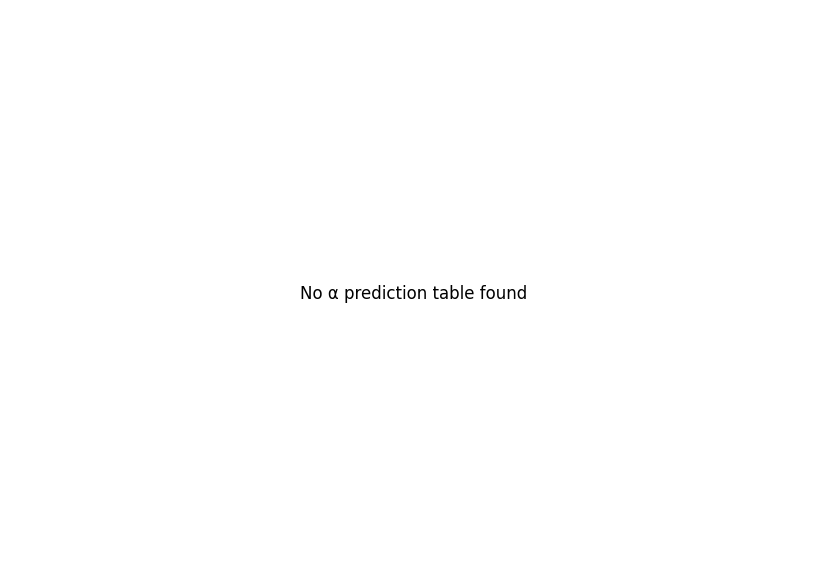

Saved plots:
  /content/drive/MyDrive/folding_drafter_result/folding_result/speedup_vs_k.png
  /content/drive/MyDrive/folding_drafter_result/folding_result/acceptance_vs_k.png
  /content/drive/MyDrive/folding_drafter_result/folding_result/cnn_vs_hmm_acceptance_scatter.png
  /content/drive/MyDrive/folding_drafter_result/folding_result/speedup_vs_length.png
  /content/drive/MyDrive/folding_drafter_result/folding_result/latency_comparison.png
  /content/drive/MyDrive/folding_drafter_result/folding_result/predicted_vs_measured.png


In [4]:
# @title 3. Plots: CNN vs HMM drafter comparison (separate files per plot). { display-mode: "form" }
import matplotlib.pyplot as plt

COLORS = {
    "cnn": "steelblue", "hmm": "darkorange", "pa_hmm": "forestgreen",
    "PU": "darkorange", "PA": "forestgreen", "flexprofile": "steelblue",
}
MARKERS_DYN = {"cnn": "s", "hmm": "D", "pa_hmm": "^", "PU": "D", "PA": "^", "flexprofile": "s"}

def _drafter_color(drafter):
    return COLORS.get(drafter, DRAFTER_COLOR.get(drafter, None))

def _mean_k(series):
    return series.apply(lambda h: np.mean(h) if isinstance(h, list) and h else float("nan"))

best_k = fixed_df.groupby("K")["speedup"].median().idxmax() if len(fixed_df) > 0 else (K_VALUES[0] if K_VALUES else 1)
K_compare = 4 if 4 in K_VALUES else (K_VALUES[0] if K_VALUES else best_k)
saved_paths = []

def _finish(fig, ax, fname, legend=True):
    """Tighten, save, show and close a single-plot figure."""
    if legend:
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(fontsize=8)
    fig.tight_layout()
    path = PLOT_OUTPUT_DIR / fname
    fig.savefig(path, dpi=150)
    plt.show()
    plt.close(fig)
    saved_paths.append(path)

# 1) Speedup vs K — fixed + dynamic
fig, ax = plt.subplots(figsize=(7, 5))
for drafter in DRAFTER_ORDER:
    sub = fixed_df[fixed_df["drafter"] == drafter]
    if len(sub) > 0:
        by_k = sub.groupby("K")["speedup"].median()
        by_k_q1 = sub.groupby("K")["speedup"].quantile(0.25)
        by_k_q3 = sub.groupby("K")["speedup"].quantile(0.75)
        ax.errorbar(by_k.index, by_k.values,
                    yerr=[by_k.values - by_k_q1.values, by_k_q3.values - by_k.values],
                    fmt="o-", label=drafter, color=_drafter_color(drafter), capsize=3, alpha=0.8)
    dyn_sub = dyn_df[dyn_df["drafter"] == drafter] if len(dyn_df) else pd.DataFrame()
    if len(dyn_sub) > 0:
        dyn_mean_k = _mean_k(dyn_sub["k_history"]).mean() if "k_history" in dyn_sub.columns else dyn_sub.get("mean_k", pd.Series(dtype=float)).mean()
        dyn_speedup_vals = dyn_sub["speedup"].dropna()
        if len(dyn_speedup_vals):
            dyn_speedup_med = dyn_speedup_vals.median()
            dyn_q1 = dyn_speedup_vals.quantile(0.25)
            dyn_q3 = dyn_speedup_vals.quantile(0.75)
            ax.errorbar([dyn_mean_k], [dyn_speedup_med],
                        yerr=[[dyn_speedup_med - dyn_q1], [dyn_q3 - dyn_speedup_med]],
                        fmt=MARKERS_DYN.get(drafter, "s"), color=_drafter_color(drafter), capsize=3,
                        markersize=8, zorder=5,
                        label=f"{drafter} dynamic (mean_K={dyn_mean_k:.1f})")
ax.axhline(1.0, color="red", linestyle="--", alpha=0.4, label="breakeven")
ax.set_xlabel("Draft length K")
ax.set_ylabel("Median speedup over enc-dec")
ax.set_title("Speedup vs. K (error bars = IQR)")
ax.grid(True, alpha=0.3)
_finish(fig, ax, "speedup_vs_k.png")

# 2) Acceptance rate vs K — fixed + dynamic when acceptance is available
fig, ax = plt.subplots(figsize=(7, 5))
plotted_acceptance = False
for drafter in DRAFTER_ORDER:
    sub = fixed_df[fixed_df["drafter"] == drafter]
    if "acceptance_rate" in sub.columns and sub["acceptance_rate"].notna().any():
        by_k = sub.groupby("K")["acceptance_rate"].mean()
        by_k_std = sub.groupby("K")["acceptance_rate"].std().fillna(0)
        ax.errorbar(by_k.index, by_k.values, yerr=by_k_std.values,
                    fmt="o-", label=drafter, color=_drafter_color(drafter), capsize=3, alpha=0.8)
        plotted_acceptance = True
    dyn_sub = dyn_df[dyn_df["drafter"] == drafter] if len(dyn_df) else pd.DataFrame()
    if len(dyn_sub) > 0 and "acceptance_rate" in dyn_sub.columns and dyn_sub["acceptance_rate"].notna().any():
        dyn_mean_k = _mean_k(dyn_sub["k_history"]).mean() if "k_history" in dyn_sub.columns else dyn_sub.get("mean_k", pd.Series(dtype=float)).mean()
        dyn_acc_mean = dyn_sub["acceptance_rate"].mean()
        dyn_acc_std = dyn_sub["acceptance_rate"].std()
        yerr = 0 if pd.isna(dyn_acc_std) else dyn_acc_std
        ax.errorbar([dyn_mean_k], [dyn_acc_mean],
                    yerr=[[yerr]], fmt=MARKERS_DYN.get(drafter, "s"),
                    color=_drafter_color(drafter), capsize=3, markersize=8, zorder=5,
                    label=f"{drafter} dynamic")
        plotted_acceptance = True
if not plotted_acceptance:
    ax.text(0.5, 0.5, "acceptance_rate not found\nin saved fixed-K results", ha="center", va="center", transform=ax.transAxes)
ax.set_xlabel("Draft length K")
ax.set_ylabel("Mean acceptance rate")
ax.set_title("Acceptance rate vs. K (error bars = ±1 SD)")
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
_finish(fig, ax, "acceptance_vs_k.png")

# 3) Pairwise acceptance scatter (shared proteins)
fig, ax = plt.subplots(figsize=(7, 5))
scatter_pair = DRAFTER_ORDER[:2]
if len(scatter_pair) >= 2 and "acceptance_rate" in fixed_df.columns:
    left = fixed_df[(fixed_df["drafter"] == scatter_pair[0]) & (fixed_df["K"] == K_compare)].set_index("protein_id")
    right = fixed_df[(fixed_df["drafter"] == scatter_pair[1]) & (fixed_df["K"] == K_compare)].set_index("protein_id")
    shared = left.index.intersection(right.index)
else:
    left = right = pd.DataFrame()
    shared = []
if len(shared) > 0 and left.loc[shared, "acceptance_rate"].notna().any() and right.loc[shared, "acceptance_rate"].notna().any():
    ax.scatter(left.loc[shared, "acceptance_rate"], right.loc[shared, "acceptance_rate"], alpha=0.6, s=20)
    lim = max(left.loc[shared, "acceptance_rate"].max(), right.loc[shared, "acceptance_rate"].max()) * 1.05
    ax.plot([0, lim], [0, lim], "r--", alpha=0.4, label=f"{scatter_pair[0]} == {scatter_pair[1]}")
    ax.set_xlabel(f"{scatter_pair[0]} acceptance rate (K={K_compare})")
    ax.set_ylabel(f"{scatter_pair[1]} acceptance rate (K={K_compare})")
    ax.set_title(f"{scatter_pair[0]} vs {scatter_pair[1]} acceptance (shared proteins)")
    ax.grid(True, alpha=0.3)
    _finish(fig, ax, "cnn_vs_hmm_acceptance_scatter.png")
else:
    ax.text(0.5, 0.5, "No shared acceptance-rate rows yet", ha="center", va="center", transform=ax.transAxes)
    ax.set_axis_off()
    _finish(fig, ax, "cnn_vs_hmm_acceptance_scatter.png", legend=False)

# 4) Speedup vs length — best fixed K, all drafters
fig, ax = plt.subplots(figsize=(7, 5))
for drafter in DRAFTER_ORDER:
    sub = fixed_df[(fixed_df["drafter"] == drafter) & (fixed_df["K"] == best_k)]
    ax.scatter(sub["length"], sub["speedup"], alpha=0.5, s=15,
               label=drafter, color=_drafter_color(drafter))
ax.axhline(1.0, color="red", linestyle="--", alpha=0.4)
ax.set_xscale("log")
ax.set_xlabel("Protein length")
ax.set_ylabel(f"Speedup (K={best_k})")
ax.set_title(f"Speedup vs. length (best fixed K={best_k})")
ax.grid(True, alpha=0.3)
_finish(fig, ax, "speedup_vs_length.png")

# 5) Latency: enc-dec vs assisted drafters (best fixed K)
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(encdec_df["length"], encdec_df["wall_s"], alpha=0.5, s=15,
           label="enc-dec", color="gray")
for drafter in DRAFTER_ORDER:
    sub = fixed_df[(fixed_df["drafter"] == drafter) & (fixed_df["K"] == best_k)]
    ax.scatter(sub["length"], sub["wall_s"], alpha=0.5, s=15,
               label=f"spec {drafter} K={best_k}", color=_drafter_color(drafter))
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Protein length")
ax.set_ylabel("Wall time (s)")
ax.set_title("Latency comparison")
ax.grid(True, which="both", alpha=0.3)
_finish(fig, ax, "latency_comparison.png")

# 6) Predicted vs measured, if available
fig, ax = plt.subplots(figsize=(7, 5))
if len(comp_df) > 0 and {"predicted_tok_per_step", "measured_tok_per_step"}.issubset(comp_df.columns):
    ax.scatter(comp_df["predicted_tok_per_step"], comp_df["measured_tok_per_step"], alpha=0.4, s=15)
    max_val = max(comp_df["predicted_tok_per_step"].max(), comp_df["measured_tok_per_step"].max())
    ax.plot([0, max_val], [0, max_val], "r--", alpha=0.5, label="perfect prediction")
    ax.set_xlabel("Predicted tokens/step (α, Theorem 3.8)")
    ax.set_ylabel("Measured tokens/step")
    ax.set_title("Predicted vs. measured")
    ax.grid(True, alpha=0.3)
    _finish(fig, ax, "predicted_vs_measured.png")
else:
    ax.text(0.5, 0.5, "No α prediction table found", ha="center", va="center", transform=ax.transAxes)
    ax.set_axis_off()
    _finish(fig, ax, "predicted_vs_measured.png", legend=False)

print("Saved plots:")
for p in saved_paths:
    print(f"  {p}")


In [5]:
# @title 4. Dynamic K behavior analysis (separate files per plot). { display-mode: "form" }
if len(dyn_df) == 0:
    print("No dynamic K results yet.")
else:
    saved_paths = []

    def _finish(fig, ax, fname, legend=True):
        """Tighten, save, show and close a single-plot figure."""
        if legend:
            handles, labels = ax.get_legend_handles_labels()
            if handles:
                ax.legend()
        fig.tight_layout()
        path = PLOT_OUTPUT_DIR / fname
        fig.savefig(path, dpi=150)
        plt.show()
        plt.close(fig)
        saved_paths.append(path)

    # 1) Distribution of mean_K across proteins, per drafter
    fig, ax = plt.subplots(figsize=(7, 5))
    for drafter in DRAFTER_ORDER:
        sub = dyn_df[dyn_df["drafter"] == drafter]
        if len(sub) == 0:
            continue
        if "k_history" in sub.columns:
            mean_ks = sub["k_history"].apply(lambda h: np.mean(h) if isinstance(h, list) and h else float("nan")).dropna()
        else:
            mean_ks = pd.to_numeric(sub.get("mean_k", pd.Series(dtype=float)), errors="coerce").dropna()
        ax.hist(mean_ks, bins=15, alpha=0.6, label=drafter, color=_drafter_color(drafter))
    ax.axvline(K_CAP_DYN, color="gray", linestyle="--", alpha=0.5, label="K_cap")
    ax.set_xlabel("Mean K over sequence")
    ax.set_ylabel("Number of proteins")
    ax.set_title("Distribution of mean dynamic K")
    ax.grid(True, alpha=0.3)
    _finish(fig, ax, "dynamic_k_distribution.png")

    # 2) K trace for representative proteins from the first dynamic drafter
    trace_drafter = next((d for d in DRAFTER_ORDER if len(dyn_df[dyn_df["drafter"] == d]) > 0), dyn_df["drafter"].iloc[0])
    fig, ax = plt.subplots(figsize=(7, 5))
    trace_dyn = dyn_df[dyn_df["drafter"] == trace_drafter].copy()
    if "k_history" in trace_dyn.columns:
        trace_dyn["mean_k"] = trace_dyn["k_history"].apply(lambda h: np.mean(h) if isinstance(h, list) and h else float("nan"))
        trace_dyn_sorted = trace_dyn.dropna(subset=["mean_k"]).sort_values("mean_k")
        representatives = pd.concat([trace_dyn_sorted.head(3), trace_dyn_sorted.tail(3)]).drop_duplicates(subset=["protein_id"])
        cmap = plt.cm.RdYlGn
        for i, (_, row) in enumerate(representatives.iterrows()):
            hist = row["k_history"]
            if not isinstance(hist, list) or len(hist) == 0:
                continue
            color = cmap(i / max(len(representatives) - 1, 1))
            label = f"{row['protein_id']} (L={row['length']}, mean_K={row['mean_k']:.1f})"
            ax.plot(hist, alpha=0.8, linewidth=1, color=color, label=label)
    ax.axhline(K_CAP_DYN, color="gray", linestyle="--", alpha=0.4, label="K_cap")
    ax.set_xlabel("Decoding step")
    ax.set_ylabel("K used")
    ax.set_title(f"K trace — 3 easiest & 3 hardest proteins ({trace_drafter})")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc="upper right")
    _finish(fig, ax, "dynamic_k_trace.png", legend=False)

    # 3) mean_K vs acceptance rate scatter
    fig, ax = plt.subplots(figsize=(7, 5))
    for drafter in DRAFTER_ORDER:
        sub = dyn_df[dyn_df["drafter"] == drafter].copy()
        if len(sub) == 0 or "acceptance_rate" not in sub.columns:
            continue
        if "k_history" in sub.columns:
            sub["mean_k"] = sub["k_history"].apply(lambda h: np.mean(h) if isinstance(h, list) and h else float("nan"))
        ax.scatter(sub["acceptance_rate"], sub["mean_k"], alpha=0.5, s=15, label=drafter, color=_drafter_color(drafter))
    ax.axhline(K_CAP_DYN, color="gray", linestyle="--", alpha=0.4, label="K_cap")
    ax.set_xlabel("Acceptance rate")
    ax.set_ylabel("Mean K over sequence")
    ax.set_title("Acceptance rate vs. mean dynamic K")
    ax.grid(True, alpha=0.3)
    _finish(fig, ax, "dynamic_k_vs_acceptance.png")

    print("Saved plots:")
    for p in saved_paths:
        print(f"  {p}")

    print("\n=== Dynamic K summary ===")
    for drafter in DRAFTER_ORDER:
        sub = dyn_df[dyn_df["drafter"] == drafter].copy()
        if len(sub) == 0:
            continue
        if "k_history" in sub.columns:
            sub["mean_k"] = sub["k_history"].apply(lambda h: np.mean(h) if isinstance(h, list) and h else float("nan"))
        print(f"\n{drafter.upper()}:")
        print(f"  Mean K (across proteins): {sub['mean_k'].mean():.2f}  "
              f"(K_init=5, range [{sub['mean_k'].min():.1f}, {sub['mean_k'].max():.1f}])")
        print(f"  Speedup: mean={sub['speedup'].mean():.2f}x  median={sub['speedup'].median():.2f}x")
        if "acceptance_rate" in sub.columns:
            print(f"  Acceptance rate: {sub['acceptance_rate'].mean():.3f}")

    print("\n=== Confidence-dyn vs fixed-K (matched draft length) ===")
    for drafter in DRAFTER_ORDER:
        dsub = dyn_df[dyn_df["drafter"] == drafter]
        fsub = fixed_df[fixed_df["drafter"] == drafter]
        if len(dsub) == 0 or len(fsub) == 0:
            continue
        dmk = dsub["k_history"].apply(lambda h: np.mean(h) if isinstance(h, list) and h else float("nan")).mean() if "k_history" in dsub.columns else dsub["mean_k"].mean()
        kgrid = sorted(fsub["K"].unique())
        kbest = min(kgrid, key=lambda k: abs(k - dmk))
        msg = f"  {drafter:6s}: conf-dyn mean_K={dmk:.1f}"
        if "acceptance_rate" in dsub.columns and "acceptance_rate" in fsub.columns:
            dacc = dsub["acceptance_rate"].mean()
            facc = fsub[fsub["K"] == kbest]["acceptance_rate"].mean()
            msg += f" accept={dacc:.2f}  vs  fixed K={kbest} accept={facc:.2f}"
        else:
            msg += f"  vs  fixed K={kbest}"
        msg += f"  (dyn drafts {(dmk / kbest - 1) * 100:+.0f}% tokens vs K={kbest})"
        print(msg)

if 'recovery_df' in globals() and len(recovery_df):
    fig, ax = plt.subplots(figsize=(7, 5))
    for d in sorted(recovery_df["drafter"].unique()):
        s = recovery_df[recovery_df["drafter"] == d]
        ax.scatter(s["length"], s["recovery"], s=15, alpha=0.5, marker=DRAFTER_MARKER.get(d, "o"), label=d, color=_drafter_color(d))
    ax.set_xlabel("Protein length")
    ax.set_ylabel("Recovery vs GT 3Di")
    ax.set_ylim(0, 1)
    ax.set_title("Sequence recovery vs protein length")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    path = PLOT_OUTPUT_DIR / "sequence_recovery_vs_length.png"
    fig.savefig(path, dpi=150)
    plt.show()
    plt.close(fig)
    print(f"saved {path}")


No dynamic K results yet.


In [6]:
# @title 5. Final summary
print("=" * 72)
print("FINAL SUMMARY - ProstT5 Folding Speculative Decoding Results")
print("=" * 72)
print(f"Results root       : {RESULTS_ROOT}")
print(f"Plot output folder : {PLOT_OUTPUT_DIR}")
print(f"Finished proteins  : {len(finished_ids)} / {len(all_ids)}")
print(f"Drafters           : {', '.join(DRAFTERS)}")
print(f"Static K values    : {STATIC_K}")
print()
for d in DRAFTERS:
    s = summary[summary["drafter"] == d].sort_values("speedup_mean", ascending=False)
    if s.empty:
        continue
    best = s.iloc[0]
    print(f"{DRAFTER_LABEL.get(d, d)}")
    print(f"  best static K    : K={int(best['K'])} -> mean {best['speedup_mean']:.2f}x, median {best['speedup_median']:.2f}x over {int(best['proteins'])} proteins")
    for _, row in summary[summary["drafter"] == d].sort_values("K").iterrows():
        print(f"  K={int(row['K']):>2}: proteins={int(row['proteins']):>3}, mean={row['speedup_mean']:.2f}x, median={row['speedup_median']:.2f}x")
    if len(dynamic_df):
        dyn = dynamic_df[dynamic_df["drafter"] == d]
        if len(dyn):
            pieces = [f"dynamic K: proteins={dyn['id'].nunique()}, mean speedup={dyn['speedup'].mean():.2f}x"]
            if "mean_k" in dyn.columns:
                pieces.append(f"mean_K={pd.to_numeric(dyn['mean_k'], errors='coerce').mean():.1f}")
            if "acceptance_rate" in dyn.columns:
                pieces.append(f"accept={pd.to_numeric(dyn['acceptance_rate'], errors='coerce').mean():.3f}")
            print("  " + ", ".join(pieces))
    print()

# Lightweight markdown report for copy/paste into notes.
report_lines = [
    "# ProstT5 Folding Result Summary",
    "",
    f"- Results root: `{RESULTS_ROOT}`",
    f"- Finished proteins: **{len(finished_ids)} / {len(all_ids)}**",
    f"- Drafters: {', '.join(DRAFTERS)}",
    f"- Static K values: {STATIC_K}",
    "",
    "## Best Static K By Drafter",
]
for _, row in best_by_drafter.iterrows():
    report_lines.append(f"- {DRAFTER_LABEL.get(row['drafter'], row['drafter'])}: K={int(row['K'])}, mean speedup={row['speedup_mean']:.2f}x over {int(row['proteins'])} proteins")
report_path = PLOT_OUTPUT_DIR / "summary.md"
report_path.write_text("\n".join(report_lines) + "\n")
print(f"Wrote {report_path}")
print("=" * 72)


FINAL SUMMARY - ProstT5 Folding Speculative Decoding Results
Results root       : /content/drive/MyDrive/folding_drafter_result
Plot output folder : /content/drive/MyDrive/folding_drafter_result/folding_result
Finished proteins  : 97 / 100
Drafters           : PA, PU, cnn, flexprofile
Static K values    : [1, 4, 8, 12]

PA (prefix-aware profile)
  best static K    : K=12 -> mean 5.97x, median 6.33x over 97 proteins
  K= 1: proteins= 97, mean=1.59x, median=1.57x
  K= 4: proteins= 97, mean=3.29x, median=3.31x
  K= 8: proteins= 97, mean=4.77x, median=4.83x
  K=12: proteins= 97, mean=5.97x, median=6.33x

PU (prefix-unaware profile)
  best static K    : K=12 -> mean 5.09x, median 5.48x over 97 proteins
  K= 1: proteins= 97, mean=1.52x, median=1.54x
  K= 4: proteins= 97, mean=3.00x, median=3.16x
  K= 8: proteins= 97, mean=4.19x, median=4.47x
  K=12: proteins= 97, mean=5.09x, median=5.48x

Folding CNN
  best static K    : K=1 -> mean 0.92x, median 0.92x over 100 proteins
  K= 1: proteins=100,